In [4]:
%pip install tensorflow-datasets

Note: you may need to restart the kernel to use updated packages.


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [7]:
%pip install importlib-resources

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Load Rock Paper Scissors dataset

(train_ds, test_ds) = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    as_supervised=True,
    batch_size=-1
)

x_train, y_train = tfds.as_numpy(train_ds)
x_test, y_test = tfds.as_numpy(test_ds)

print("Original train shape:", x_train.shape)
print("Original test shape:", x_test.shape)

c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 100%|██████████| 2/2 [03:50<00:00, 115.37s/ url]


Dataset rock_paper_scissors downloaded and prepared to C:\Users\moham\tensorflow_datasets\rock_paper_scissors\3.0.0. Subsequent calls will reuse this data.



Original train shape: (2520, 300, 300, 3)
Original test shape: (372, 300, 300, 3)


In [9]:
# Resize images to reduce computation

IMG_SIZE = 64

x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE)).numpy()
x_test = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE)).numpy()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [10]:
# One-hot encode labels

y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

x_train shape:  (2520, 64, 64, 3)
x_test shape:  (372, 64, 64, 3)
y_train shape:  (2520, 3)
y_test shape:  (372, 3)


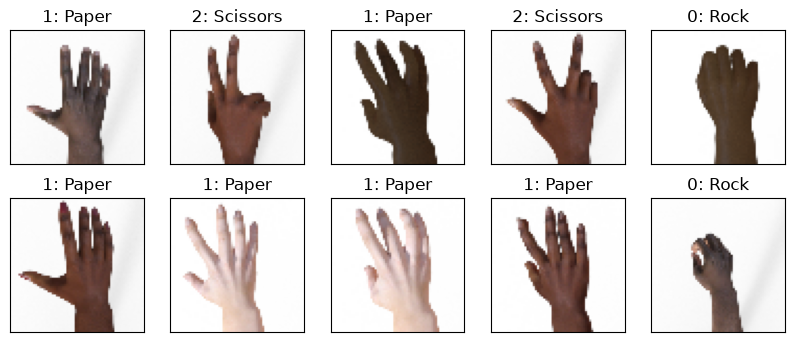

In [11]:
# Visualize samples

class_names = {
    0: 'Rock',
    1: 'Paper',
    2: 'Scissors'
}

idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]

plt.figure(figsize=(10, 4))

for i, j in enumerate(idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[j])
    plt.xticks([])
    plt.yticks([])
    label = np.argmax(y_train[j])
    plt.title(str(label) + ": " + class_names[label])

plt.show()

In [12]:
model1 = models.Sequential()

In [13]:
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

# Input dimensions
inpt_dim = (64, 64, 3)
inpt_img = Input(shape=inpt_dim)

# First convolutional layer
c11 = Conv2D(
    64,
    (9, 9),
    strides=(2, 2),
    activation='relu'
)(inpt_img)

# Pooling and BatchNorm
p12 = MaxPooling2D(pool_size=(2, 2))(c11)
bn13 = BatchNormalization()(p12)

# Second convolutional layer
c14 = Conv2D(
    128,
    (3, 3),
    strides=(1, 1),
    activation='relu'
)(bn13)

p15 = MaxPooling2D(pool_size=(2, 2))(c14)
bn16 = BatchNormalization()(p15)

# Flatten
f17 = Flatten()(bn16)

# Dense + Dropout
do18 = Dropout(0.5)(f17)
d19 = Dense(256, activation='relu')(do18)

do110 = Dropout(0.2)(d19)
d111 = Dense(64, activation='relu')(do110)

do112 = Dropout(0.1)(d111)

# 3 classes: Rock, Paper, Scissors
output = Dense(3, activation='softmax')(do112)

classifier = Model(inpt_img, output)

In [14]:
opt = RMSprop(learning_rate=0.001)

classifier.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(classifier.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,787 (4.91 MB)

 Trainable params: 1,286,403 (4.91 MB)

 Non-trainable params: 384 (1.50 KB)

None


In [15]:
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

checkpoint_filepath = 'rps_cnn_model.keras'

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [16]:
# Fitting the CNN to the images

hist = classifier.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    callbacks=[
        stop_alg,
        reduce_lr,
        model_checkpoint
    ],
    shuffle=True,
    validation_data=(x_test, y_test)
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8234 - loss: 0.6451 - val_accuracy: 0.5108 - val_loss: 1.3691 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9865 - loss: 0.0515 - val_accuracy: 0.6505 - val_loss: 1.1162 - learning_rate: 0.0010
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9913 - loss: 0.0340 - val_accuracy: 0.4946 - val_loss: 2.6562 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9992 - loss: 0.0059 - val_accuracy: 0.6156 - val_loss: 2.2401 - learning_rate: 0.0010
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9988 - loss: 0.0123 - val_accuracy: 0.8280 - val_loss: 0.3707 - learning_rate: 0.0010
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9956 - loss: 0.0194 - val_accuracy: 0.9140 - val_loss: 0.2880 - learning_rate: 0.0010
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9992 - loss: 0.0017 - val_acc

In [17]:
classifier.save_weights("rps_cnn.weights.h5")

In [18]:
classifier.load_weights("rps_cnn.weights.h5")

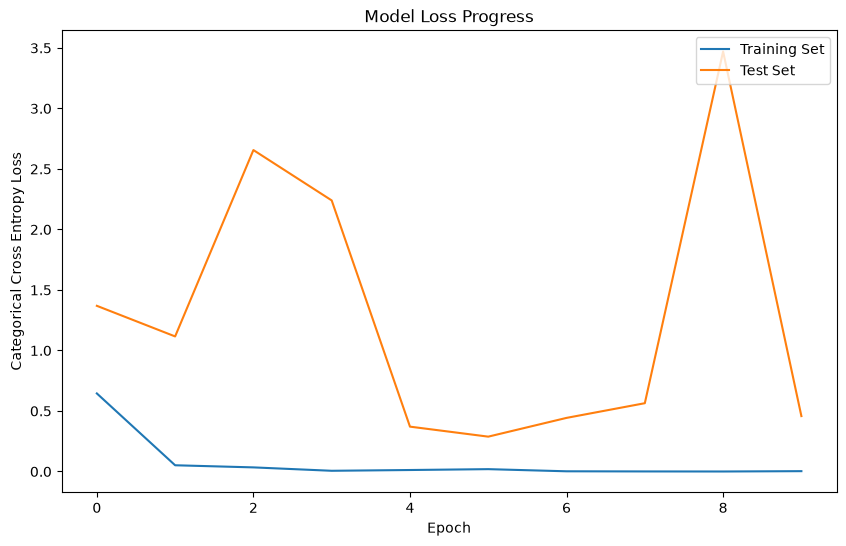

In [19]:
# Plot loss

plt.figure(figsize=(10, 6))

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

plt.title('Model Loss Progress')
plt.ylabel('Categorical Cross Entropy Loss')
plt.xlabel('Epoch')

plt.legend(
    ['Training Set', 'Test Set'],
    loc='upper right'
)

plt.show()

In [21]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 833.7 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.2 MB 944.7 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.2 MB 990.4 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.2 MB 990.4 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.2 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.2 MB 1.0 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.0 MB/s eta 0:00:07
   ---------- ----------------------------- 2.1/8.2 MB 1.0 MB/s eta 0:00:06
   ---------- ----------------------------- 2

In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

# Predictions
y_hat = classifier.predict(x_test)

y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=['Rock', 'Paper', 'Scissors']
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2]
)

print("Confusion Matrix:")
print(cm)

# BER
ber = 1 - balanced_accuracy_score(y_true, y_pred)

print("BER:", ber)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

        Rock       0.96      0.86      0.91       124
       Paper       0.92      0.88      0.90       124
    Scissors       0.88      1.00      0.94       124

    accuracy                           0.91       372
   macro avg       0.92      0.91      0.91       372
weighted avg       0.92      0.91      0.91       372

Confusion Matrix:
[[107  10   7]
 [  5 109  10]
 [  0   0 124]]
BER: 0.08602150537634401


In [23]:
# Test accuracy

test_loss, test_acc = classifier.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Test Accuracy:", test_acc)

12/12 - 0s - 12ms/step - accuracy: 0.9140 - loss: 0.2880
Test Accuracy: 0.9139785170555115


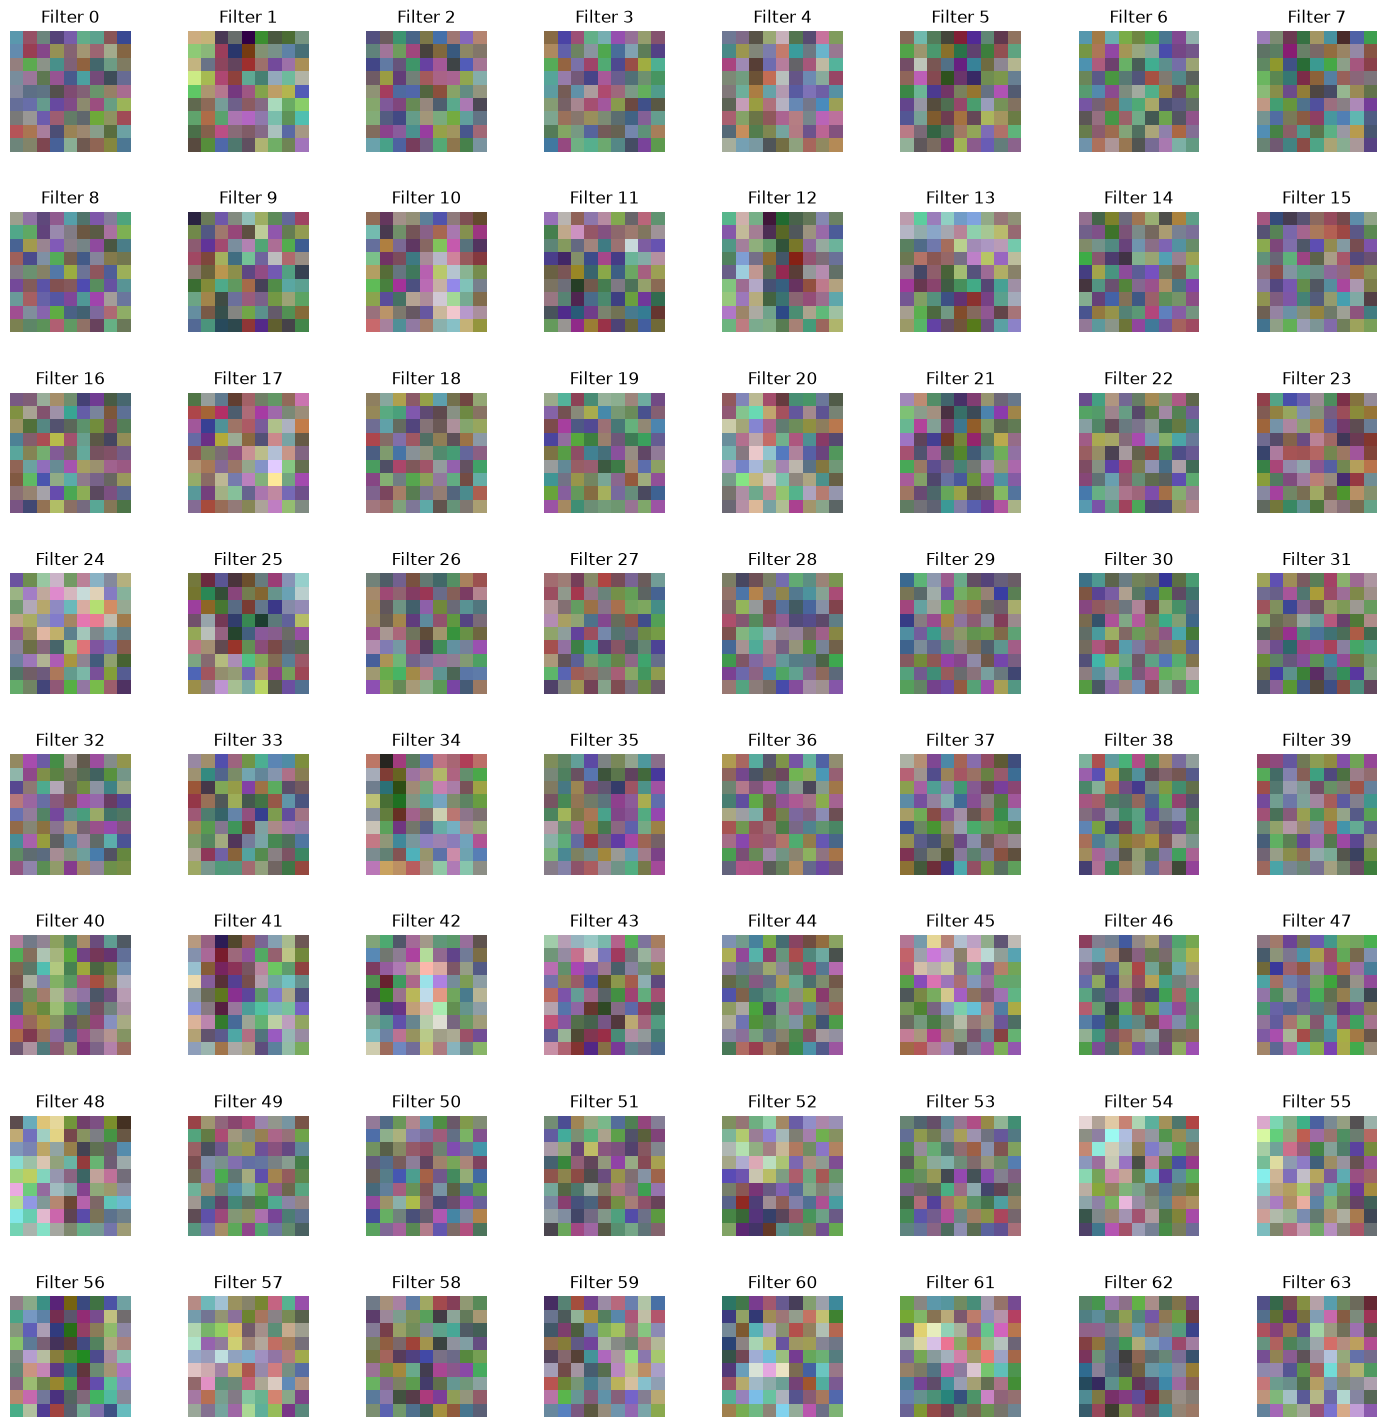

In [24]:
from sklearn.preprocessing import MinMaxScaler

# Get first convolutional layer
conv_layer = classifier.layers[1]

w = conv_layer.get_weights()[0]
wshape = w.shape

# Scale weights to [0,1] for visualization
scaler = MinMaxScaler()
scaler.fit(w.reshape(-1, 1))

w = scaler.transform(w.reshape(-1, 1))
w = w.reshape(wshape)

# Display first 64 filters
fig, axs = plt.subplots(8, 8, figsize=(18, 18))
fig.subplots_adjust(hspace=0.5, wspace=0.2)

axs = axs.ravel()

for i in range(min(64, w.shape[-1])):
    h = np.reshape(w[:, :, :, i], (9, 9, 3))
    axs[i].imshow(h)
    axs[i].set_title('Filter ' + str(i))
    axs[i].axis('off')

plt.show()